In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df_data = pd.read_csv('datasets/opentender_clean_2022_2024.csv')

In [4]:
df_data.head()

,ocid,buyer_name,vendor_name,HPS,contract_value,procurement_method,category,item_description,date
0,ocds-20h3g7-12482010,Pemerintah Daerah Kota Surabaya,PT. DUTA BHUANA JAYA,7.445028e+08,6.666604e+08,consultancyServices,services,Jasa Konsultansi Badan Usaha Konstruksi,2024-02-02
1,ocds-20h3g7-12487010,Pemerintah Daerah Kota Surabaya,"MARGA PERKASA,CV",4.793422e+09,4.129909e+09,NaN,works,Pekerjaan Konstruksi,2024-01-15
2,ocds-20h3g7-12492010,Pemerintah Daerah Kota Surabaya,CV. Naga Kencana Wiratama,2.255991e+09,2.012700e+09,NaN,works,Pekerjaan Konstruksi,2024-01-15
3,ocds-20h3g7-12496010,Pemerintah Daerah Kota Surabaya,CV. Tiga Points Jaya Karya,3.425503e+09,2.566207e+09,NaN,works,Pekerjaan Konstruksi,2024-01-16
4,ocds-20h3g7-12504010,Pemerintah Daerah Kota Surabaya,CV. Citra Karya,1.307263e+09,1.231890e+09,NaN,works,Pekerjaan Konstruksi,2024-01-15


In [5]:
df_data.head()
df_data.info()
df_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292852 entries, 0 to 292851
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ocid                292852 non-null  object 
 1   buyer_name          288191 non-null  object 
 2   vendor_name         164113 non-null  object 
 3   HPS                 163738 non-null  float64
 4   contract_value      164113 non-null  float64
 5   procurement_method  26328 non-null   object 
 6   category            164113 non-null  object 
 7   item_description    164113 non-null  object 
 8   date                292852 non-null  object 
dtypes: float64(2), object(7)
memory usage: 20.1+ MB


,HPS,contract_value
count,1.637380e+05,1.641130e+05
mean,3.817390e+09,3.529409e+09
std,3.461689e+10,3.307242e+10
min,1.760000e+04,1.050000e+04
25%,3.795271e+08,3.504016e+08
50%,6.947567e+08,6.399824e+08
75%,1.800000e+09,1.660123e+09
max,4.286669e+12,4.242926e+12


## EXPLORATORY DATA ANALYSIS (EDA)

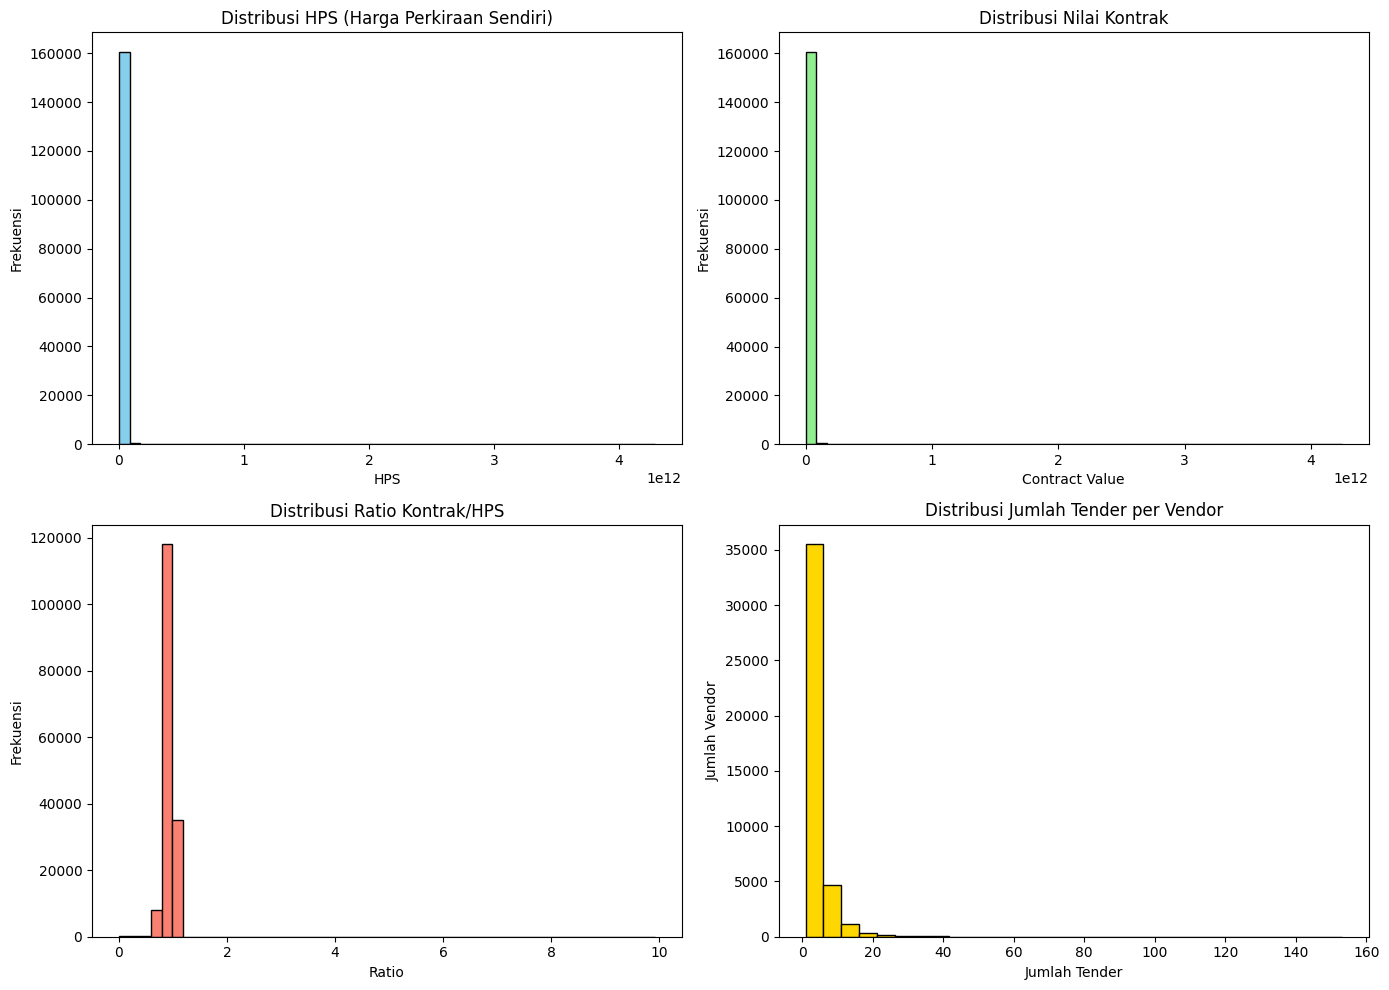

Distribution Analysis Selesai



In [32]:
import seaborn as sns

# 1. DISTRIBUTION PLOTS - KEY NUMERICAL FEATURES
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# HPS Distribution
axes[0, 0].hist(df_data['HPS'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribusi HPS (Harga Perkiraan Sendiri)', fontsize=12)
axes[0, 0].set_xlabel('HPS')
axes[0, 0].set_ylabel('Frekuensi')

# Contract Value Distribution
axes[0, 1].hist(df_data['contract_value'], bins=50, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Distribusi Nilai Kontrak', fontsize=12)
axes[0, 1].set_xlabel('Contract Value')
axes[0, 1].set_ylabel('Frekuensi')

# Discount Percentage Distribution (after feature engineering, using ratio as proxy)
axes[1, 0].hist(df_data['contract_value'] / df_data['HPS'], bins=50, color='salmon', edgecolor='black')
axes[1, 0].set_title('Distribusi Ratio Kontrak/HPS', fontsize=12)
axes[1, 0].set_xlabel('Ratio')
axes[1, 0].set_ylabel('Frekuensi')

# Vendor count distribution
vendor_counts = df_data['vendor_name'].value_counts()
axes[1, 1].hist(vendor_counts.values, bins=30, color='gold', edgecolor='black')
axes[1, 1].set_title('Distribusi Jumlah Tender per Vendor', fontsize=12)
axes[1, 1].set_xlabel('Jumlah Tender')
axes[1, 1].set_ylabel('Jumlah Vendor')

plt.tight_layout()
plt.show()

print("Distribution Analysis Selesai\n")

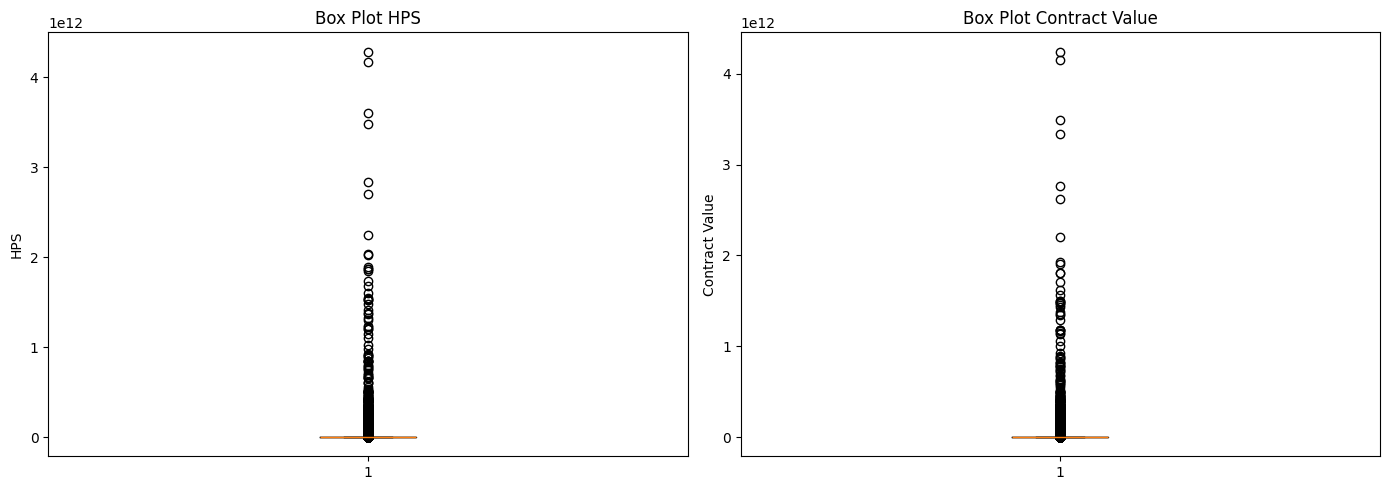

Box Plot Analysis Selesai



In [33]:
# 2. BOX PLOTS - DETEKSI OUTLIERS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot HPS
axes[0].boxplot(df_data['HPS'])
axes[0].set_title('Box Plot HPS', fontsize=12)
axes[0].set_ylabel('HPS')

# Box plot Contract Value
axes[1].boxplot(df_data['contract_value'])
axes[1].set_title('Box Plot Contract Value', fontsize=12)
axes[1].set_ylabel('Contract Value')

plt.tight_layout()
plt.show()

print("Box Plot Analysis Selesai\n")

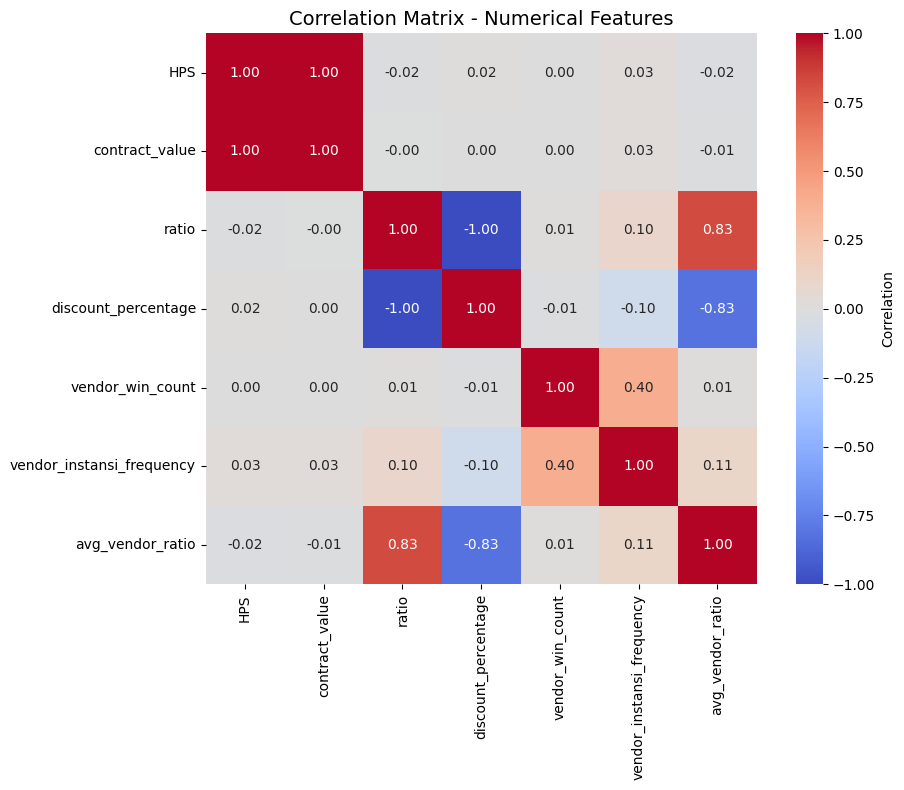

Correlation Analysis Selesai



In [34]:
# 3. CORRELATION ANALYSIS - NUMERICAL FEATURES
numerical_cols = df_data.select_dtypes(include=['float64', 'int64']).columns

# Hitung correlation hanya untuk kolom yang valid
numeric_df = df_data[numerical_cols].dropna()

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    square=True,
    cbar_kws={'label': 'Correlation'}
)
plt.title('Correlation Matrix - Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

print("Correlation Analysis Selesai\n")

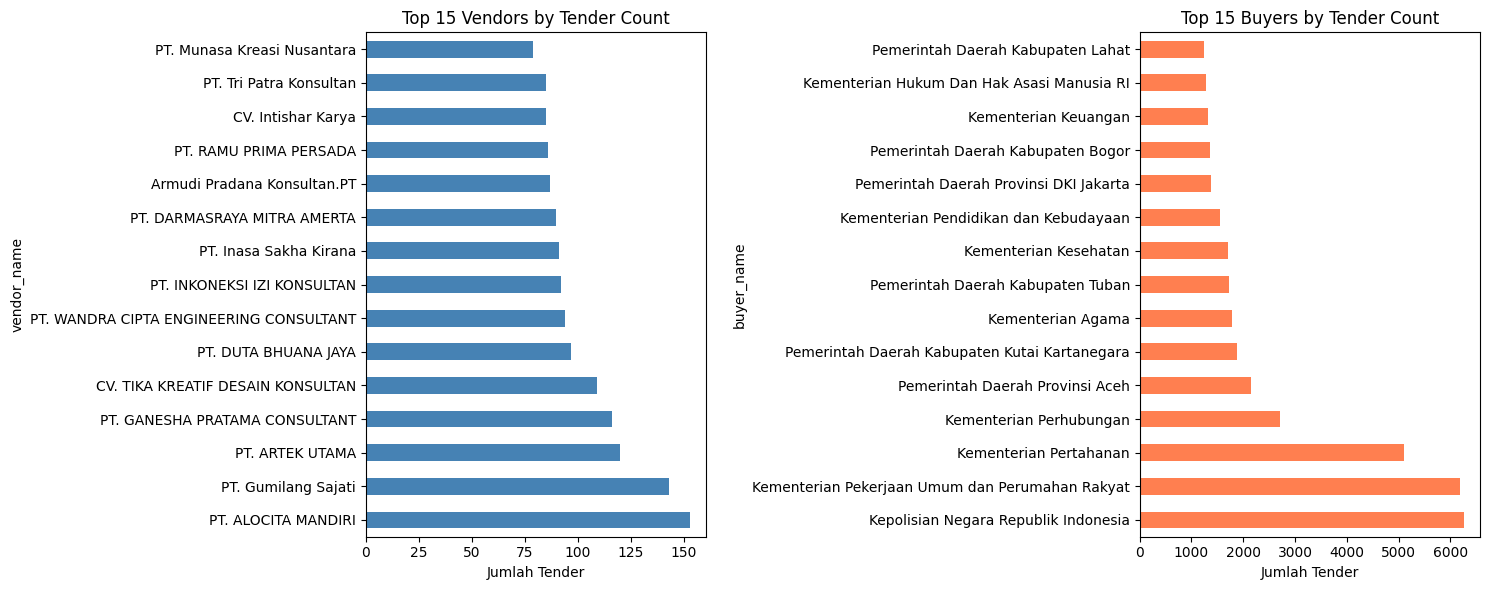

Vendor & Buyer Analysis Selesai



In [35]:
# 4. TOP VENDORS & BUYERS ANALYSIS
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 15 Vendors by Count
top_vendors = df_data['vendor_name'].value_counts().head(15)
top_vendors.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Vendors by Tender Count', fontsize=12)
axes[0].set_xlabel('Jumlah Tender')

# Top 15 Buyers by Count
top_buyers = df_data['buyer_name'].value_counts().head(15)
top_buyers.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 15 Buyers by Tender Count', fontsize=12)
axes[1].set_xlabel('Jumlah Tender')

plt.tight_layout()
plt.show()

print("Vendor & Buyer Analysis Selesai\n")

*CLEANING NOISE*

In [6]:
df_data = df_data.drop(columns=["procurement_method"])
#kudrop noise tinggi

In [7]:
df_data = df_data.dropna(subset=[
    "vendor_name",
    "contract_value"
])

In [8]:
df_data = df_data.dropna(subset=["HPS"])

In [9]:
df_data = df_data.dropna(subset=["buyer_name"])

In [10]:
df_data = df_data[df_data["HPS"] > 0]
df_data = df_data[df_data["contract_value"] > 0]

FEATURE ENGINEERING

rasio kontrak

In [11]:
#Rasio kontrak terhadap HPS
df_data["ratio"] = df_data["contract_value"] / df_data["HPS"]

In [12]:
#B. DISCOUNT PERCENTAGE
df_data["discount_percentage"] = (
    (df_data["HPS"] - df_data["contract_value"])
    / df_data["HPS"]
) * 100

In [13]:
# C. VENDOR WIN COUNT
# Berapa kali vendor menang tender

vendor_win_count = (
    df_data.groupby("vendor_name")
    .size()
    .reset_index(name="vendor_win_count")
)
# merge ke dataframe utama
df_data = df_data.merge(
    vendor_win_count,
    on="vendor_name",
    how="left"
)


In [14]:
# D. VENDOR-INSTANSI FREQUENCY
# Seberapa sering vendor menang di instansi tertentu

vendor_instansi_frequency = (
    df_data.groupby(["vendor_name", "buyer_name"])
    .size()
    .reset_index(name="vendor_instansi_frequency")
)

# merge kembali
df_data = df_data.merge(
    vendor_instansi_frequency,
    on=["vendor_name", "buyer_name"],
    how="left"
)

In [15]:
# E. AVERAGE VENDOR RATIO
# Rata-rata ratio tiap vendor

avg_vendor_ratio = (
    df_data.groupby("vendor_name")["ratio"]
    .mean()
    .reset_index(name="avg_vendor_ratio")
)

# merge kembali
df_data = df_data.merge(
    avg_vendor_ratio,
    on="vendor_name",
    how="left"
)

In [16]:
# OPTIONAL: ROUND AGAR RAPI

df_data["ratio"] = df_data["ratio"].round(4)

df_data["discount_percentage"] = (
    df_data["discount_percentage"].round(2)
)

df_data["avg_vendor_ratio"] = (
    df_data["avg_vendor_ratio"].round(4)
)

In [17]:
# CEK HASIL FEATURE ENGINEERING

print("Feature engineering selesai.\n")

print(df_data[
    [
        "vendor_name",
        "buyer_name",
        "HPS",
        "contract_value",
        "ratio",
        "discount_percentage",
        "vendor_win_count",
        "vendor_instansi_frequency",
        "avg_vendor_ratio"
    ]
].head())

# SAVE FEATURED DATASET

df_data.to_csv(
    "featured_procurement_dataset.csv",
    index=False
)

print("\nDataset berhasil disimpan.")

Feature engineering selesai.

                  vendor_name                       buyer_name           HPS  \
0        PT. DUTA BHUANA JAYA  Pemerintah Daerah Kota Surabaya  7.445028e+08   
1            MARGA PERKASA,CV  Pemerintah Daerah Kota Surabaya  4.793422e+09   
2   CV. Naga Kencana Wiratama  Pemerintah Daerah Kota Surabaya  2.255991e+09   
3  CV. Tiga Points Jaya Karya  Pemerintah Daerah Kota Surabaya  3.425503e+09   
4             CV. Citra Karya  Pemerintah Daerah Kota Surabaya  1.307263e+09   

   contract_value   ratio  discount_percentage  vendor_win_count  \
0    6.666604e+08  0.8954                10.46                97   
1    4.129909e+09  0.8616                13.84                 2   
2    2.012700e+09  0.8922                10.78                 3   
3    2.566207e+09  0.7491                25.09                 1   
4    1.231890e+09  0.9423                 5.77                 1   

   vendor_instansi_frequency  avg_vendor_ratio  
0                          6   

In [18]:
print(df_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161422 entries, 0 to 161421
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ocid                       161422 non-null  object 
 1   buyer_name                 161422 non-null  object 
 2   vendor_name                161422 non-null  object 
 3   HPS                        161422 non-null  float64
 4   contract_value             161422 non-null  float64
 5   category                   161422 non-null  object 
 6   item_description           161422 non-null  object 
 7   date                       161422 non-null  object 
 8   ratio                      161422 non-null  float64
 9   discount_percentage        161422 non-null  float64
 10  vendor_win_count           161422 non-null  int64  
 11  vendor_instansi_frequency  161422 non-null  int64  
 12  avg_vendor_ratio           161422 non-null  float64
dtypes: float64(5), int64(2), obje

**ISOLATION FOREST**

In [19]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [20]:
features = [
    "HPS",
    "contract_value",
    "ratio",
    "discount_percentage",
    "vendor_win_count",
    "vendor_instansi_frequency",
    "avg_vendor_ratio"
]

X = df_data[features]

In [21]:
X = X.dropna()

In [22]:
df_model = df_data.loc[X.index].copy()

In [23]:
df_model = df_data.loc[X.index].copy()

parameter

In [24]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [25]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42
)

FIT MODEL

In [26]:
iso_forest.fit(X_scaled)

,n_estimators,100
,max_samples,'auto'
,contamination,0.02
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [27]:
df_model["anomaly_label"] = iso_forest.predict(X_scaled)

In [28]:
df_model["anomaly_score"] = (
    iso_forest.decision_function(X_scaled)
)

In [29]:
top_anomalies = df_model.sort_values(
    by="anomaly_score"
).head(20)

In [30]:
print(top_anomalies[
    [
        "vendor_name",
        "buyer_name",
        "HPS",
        "contract_value",
        "ratio",
        "discount_percentage",
        "vendor_win_count",
        "anomaly_score"
    ]
])

                                     vendor_name  \
56104              PT BRANTAS ABIPRAYA (Persero)   
74555              PT BRANTAS ABIPRAYA (Persero)   
74429              PT BRANTAS ABIPRAYA (Persero)   
19847              PT BRANTAS ABIPRAYA (Persero)   
37721              PT BRANTAS ABIPRAYA (Persero)   
95543              PT BRANTAS ABIPRAYA (Persero)   
99362                          SAPTA KARYA ABADI   
74557            PT. WASKITA KARYA (PERSERO) Tbk   
95512            PT. WASKITA KARYA (PERSERO) Tbk   
38178   PT. Pembangunan Perumahan (Persero)  Tbk   
19684            PT. WASKITA KARYA (PERSERO) Tbk   
37893   PT. Pembangunan Perumahan (Persero)  Tbk   
38105              PT BRANTAS ABIPRAYA (Persero)   
117038  PT. Pembangunan Perumahan (Persero)  Tbk   
74790   PT. Pembangunan Perumahan (Persero)  Tbk   
138575  PT. Pembangunan Perumahan (Persero)  Tbk   
74831   PT. Pembangunan Perumahan (Persero)  Tbk   
74430                 PT. NINDYA KARYA (Persero)   
19821   PT. 

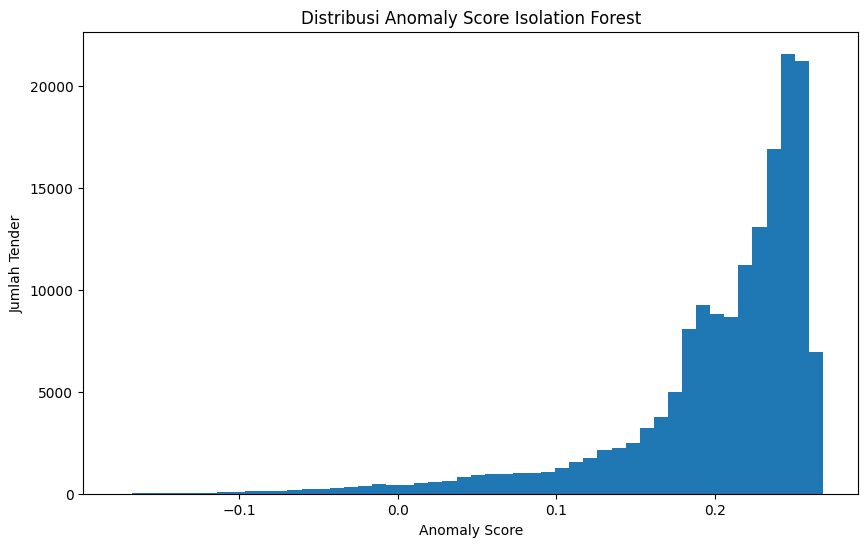

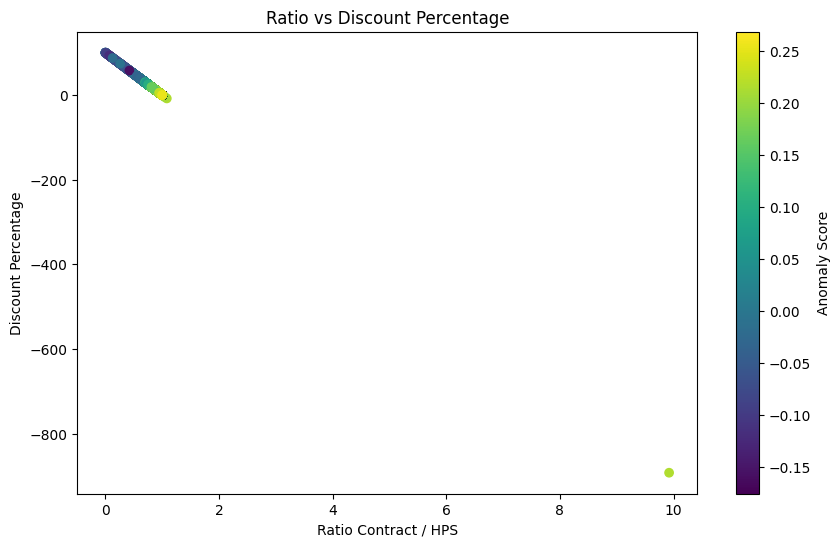

TOP SUSPICIOUS VENDORS
vendor_name
Firma KJSB Subkhi Abdul Hakim At Tigholy dan Rekan   -0.158629
PT. ENSEVAL PUTERA MEGATRADING. Tbk                  -0.151866
PT.BIOGEN SCIENTIFIC                                 -0.149281
PT. ENSEVAL PUTERA MEGATRADING, Tbk                  -0.147734
PT BRANTAS ABIPRAYA (Persero)                        -0.141380
PT. Pembangunan Perumahan (Persero)  Tbk             -0.139737
PT. WASKITA KARYA (PERSERO) Tbk                      -0.131909
PT ADHI KARYA (Persero) Tbk                          -0.123318
Admiral Blesensa Abadi                               -0.121421
PT. MITRA FAJAR SELARAS                              -0.119931
Name: anomaly_score, dtype: float64


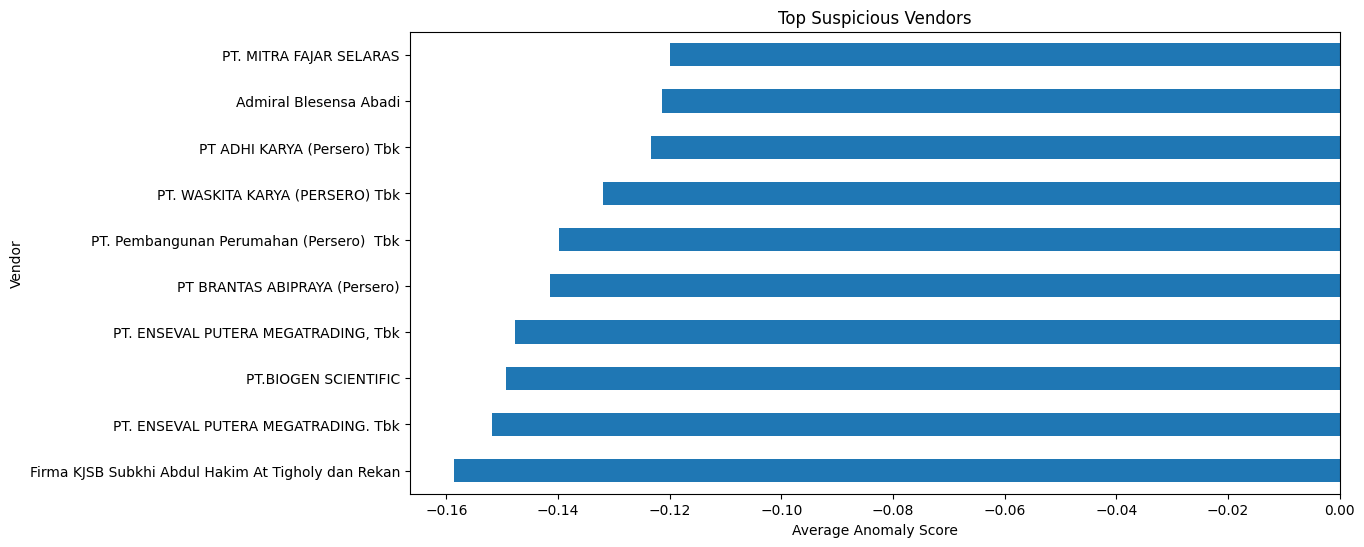

INSTANSI PALING RAWAN

buyer_name
PDAM Delta Tirta Sidoarjo                                   0.049226
PD BKK Kesugihan Kabupaten Cilacap                          0.049560
Badan Pusat Statistik                                       0.062621
Lembaga Perlindungan Saksi dan Korban Republik Indonesia    0.067784
Kementerian Pekerjaan Umum dan Perumahan Rakyat             0.084821
Pemerintah Daerah Kota Denpasar                             0.091077
Pemerintah Daerah Kabupaten Jayawijaya                      0.092993
PDAM Kabupaten Semarang                                     0.095726
PDAM Tirtamarta Yogyakarta                                  0.098016
Kejaksaan Republik Indonesia                                0.103440
Name: anomaly_score, dtype: float64


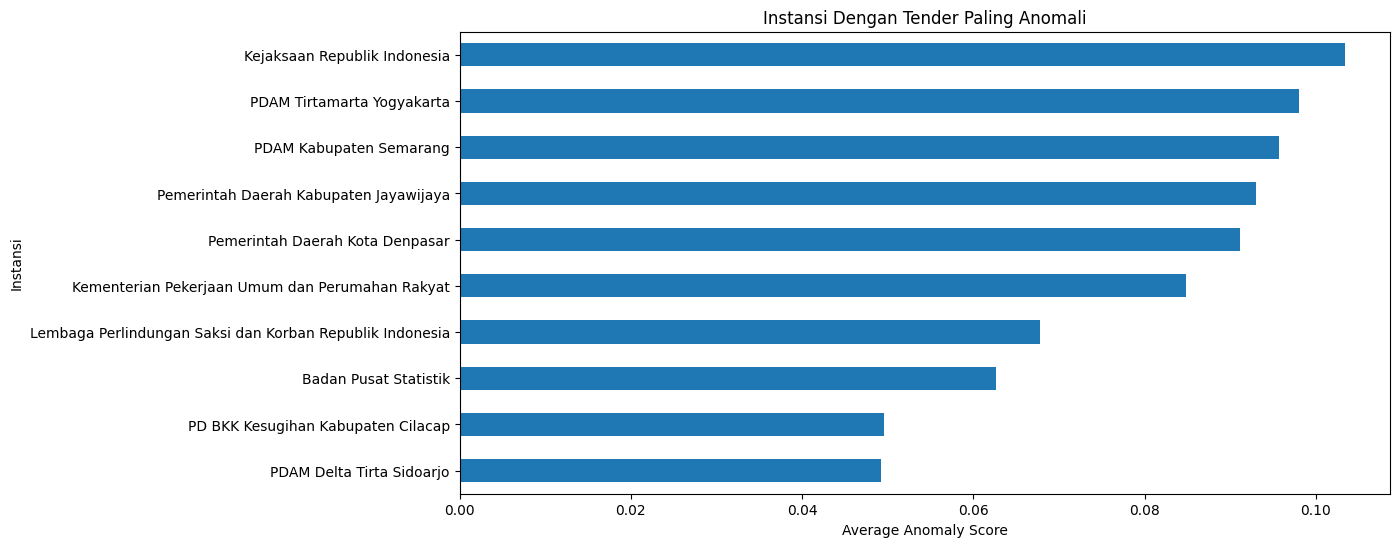

VENDOR DOMINANCE

vendor_name
PT. ALOCITA MANDIRI                        153
PT. Gumilang Sajati                        143
PT. ARTEK UTAMA                            120
PT. GANESHA PRATAMA CONSULTANT             116
CV. TIKA KREATIF DESAIN KONSULTAN          109
PT. DUTA BHUANA JAYA                        97
PT. WANDRA CIPTA ENGINEERING CONSULTANT     94
PT. INKONEKSI IZI KONSULTAN                 92
PT. Inasa Sakha Kirana                      91
PT. DARMASRAYA MITRA AMERTA                 90
Name: count, dtype: int64


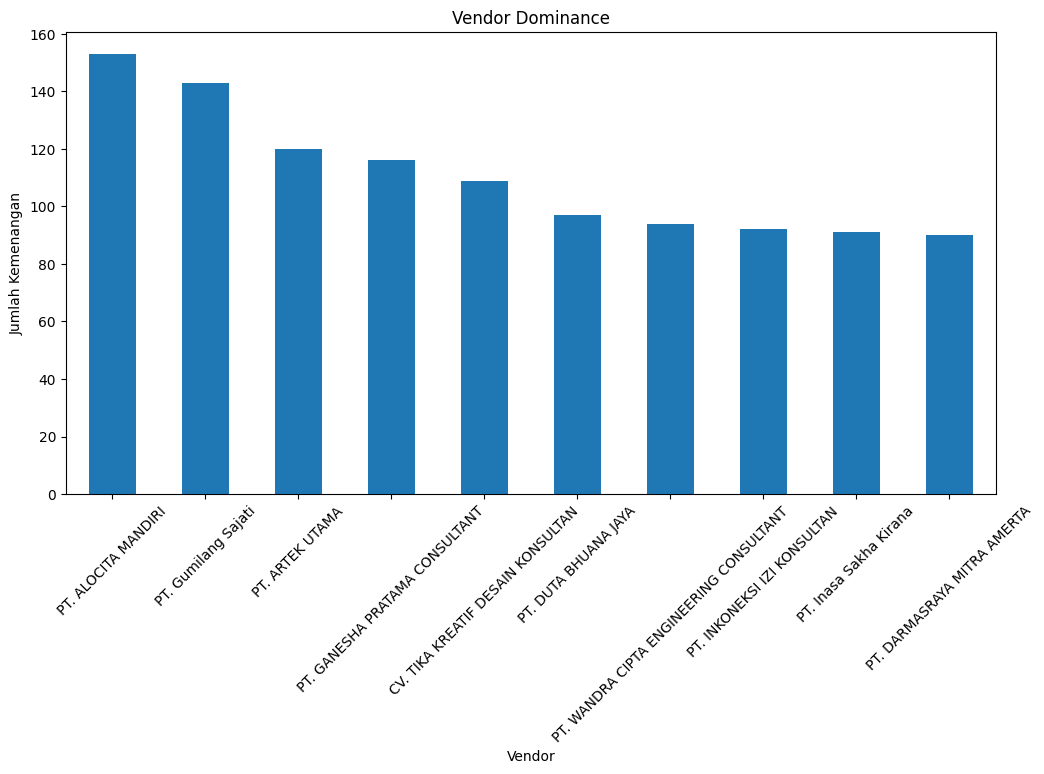

TOP 20 MOST SUSPICIOUS TENDERS

                                     vendor_name  \
56104              PT BRANTAS ABIPRAYA (Persero)   
74555              PT BRANTAS ABIPRAYA (Persero)   
74429              PT BRANTAS ABIPRAYA (Persero)   
19847              PT BRANTAS ABIPRAYA (Persero)   
37721              PT BRANTAS ABIPRAYA (Persero)   
95543              PT BRANTAS ABIPRAYA (Persero)   
99362                          SAPTA KARYA ABADI   
74557            PT. WASKITA KARYA (PERSERO) Tbk   
95512            PT. WASKITA KARYA (PERSERO) Tbk   
38178   PT. Pembangunan Perumahan (Persero)  Tbk   
19684            PT. WASKITA KARYA (PERSERO) Tbk   
37893   PT. Pembangunan Perumahan (Persero)  Tbk   
38105              PT BRANTAS ABIPRAYA (Persero)   
117038  PT. Pembangunan Perumahan (Persero)  Tbk   
74790   PT. Pembangunan Perumahan (Persero)  Tbk   
138575  PT. Pembangunan Perumahan (Persero)  Tbk   
74831   PT. Pembangunan Perumahan (Persero)  Tbk   
74430                 PT. NINDYA

In [31]:
# VISUALIZATION & DASHBOARD
# Isolation Forest Fraud Detection

import pandas as pd
import matplotlib.pyplot as plt

# 1. HISTOGRAM ANOMALY SCORE

plt.figure(figsize=(10,6))

plt.hist(
    df_model["anomaly_score"],
    bins=50
)

plt.xlabel("Anomaly Score")
plt.ylabel("Jumlah Tender")
plt.title("Distribusi Anomaly Score Isolation Forest")

plt.show()

# 2. SCATTER PLOT
# Ratio vs Discount Percentage

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df_model["ratio"],
    df_model["discount_percentage"],
    c=df_model["anomaly_score"]
)

plt.xlabel("Ratio Contract / HPS")
plt.ylabel("Discount Percentage")
plt.title("Ratio vs Discount Percentage")

plt.colorbar(scatter, label="Anomaly Score")

plt.show()

# 3. TOP SUSPICIOUS VENDORS

top_suspicious_vendors = (
    df_model.groupby("vendor_name")["anomaly_score"]
    .mean()
    .sort_values()
    .head(10)
)

print("TOP SUSPICIOUS VENDORS")
print(top_suspicious_vendors)

# VISUALISASI TOP SUSPICIOUS VENDORS

plt.figure(figsize=(12,6))

top_suspicious_vendors.plot(kind="barh")

plt.xlabel("Average Anomaly Score")
plt.ylabel("Vendor")
plt.title("Top Suspicious Vendors")

plt.show()

# 4. INSTANSI RAWAN

risky_agencies = (
    df_model.groupby("buyer_name")["anomaly_score"]
    .mean()
    .sort_values()
    .head(10)
)

print("INSTANSI PALING RAWAN\n")

print(risky_agencies)

# VISUALISASI INSTANSI RAWAN

plt.figure(figsize=(12,6))

risky_agencies.plot(kind="barh")

plt.xlabel("Average Anomaly Score")
plt.ylabel("Instansi")
plt.title("Instansi Dengan Tender Paling Anomali")

plt.show()

# 5. VENDOR DOMINANCE

vendor_dominance = (
    df_model["vendor_name"]
    .value_counts()
    .head(10)
)
print("VENDOR DOMINANCE\n")

print(vendor_dominance)

# VISUALISASI VENDOR DOMINANCE

plt.figure(figsize=(12,6))

vendor_dominance.plot(kind="bar")

plt.xlabel("Vendor")
plt.ylabel("Jumlah Kemenangan")
plt.title("Vendor Dominance")

plt.xticks(rotation=45)

plt.show()

# 6. TOP ANOMALY TABLE
top_anomalies = df_model.sort_values(
    by="anomaly_score"
).head(20)

print("TOP 20 MOST SUSPICIOUS TENDERS\n")

print(
    top_anomalies[
        [
            "vendor_name",
            "buyer_name",
            "HPS",
            "contract_value",
            "ratio",
            "discount_percentage",
            "vendor_win_count",
            "anomaly_score"
        ]
    ]
)
# OPTIONAL SAVE
top_anomalies.to_csv(
    "top_suspicious_tenders.csv",
    index=False
)

print("\nDashboard & visualisasi selesai.")

## D. GRAPH ANALYSIS - ADVANCED FRAUD DETECTION
Deteksi pola fraud kompleks: Kartel, Bid Rotation, dan Relasi Vendor

In [ ]:
import networkx as nx
from collections import defaultdict
from itertools import combinations

print("Graph Analysis Libraries loaded\n")

### 1. CARTEL DETECTION - Pola Kolaborasi Vendor Mencurigakan

In [ ]:
# Cartel: Vendor pairs yang sering menang pada buyer yang sama
# Indikasi: Beberapa vendor bekerja sama mengalahkan vendor lain pada buyer tertentu

cartel_analysis = defaultdict(list)

# Untuk setiap buyer, cari vendor yang memenangkan multiple tenders
buyer_vendors = df_model.groupby('buyer_name')['vendor_name'].apply(list).to_dict()

# Deteksi vendor pairs dengan win count tinggi pada buyer yang sama
vendor_buyer_wins = df_model.groupby(['buyer_name', 'vendor_name']).size().reset_index(name='wins')
vendor_buyer_wins = vendor_buyer_wins[vendor_buyer_wins['wins'] > 1]  # Minimal 2 kali menang

# Analisis co-occurrence: vendor yang sering menang pada buyer yang sama
cartel_scores = []

for buyer in df_model['buyer_name'].unique():
    buyer_data = df_model[df_model['buyer_name'] == buyer]
    vendors = buyer_data['vendor_name'].unique()
    
    if len(vendors) >= 2:
        # Analisis setiap pasang vendor
        for v1, v2 in combinations(vendors, 2):
            v1_wins = len(buyer_data[buyer_data['vendor_name'] == v1])
            v2_wins = len(buyer_data[buyer_data['vendor_name'] == v2])
            
            # Cartel score: combined win frequency
            if v1_wins > 0 and v2_wins > 0:
                combined_wins = v1_wins + v2_wins
                if combined_wins >= 3:  # Threshold: minimal 3 kemenangan gabungan
                    cartel_scores.append({
                        'vendor_1': v1,
                        'vendor_2': v2,
                        'buyer': buyer,
                        'vendor_1_wins': v1_wins,
                        'vendor_2_wins': v2_wins,
                        'combined_wins': combined_wins,
                        'cartel_score': (v1_wins + v2_wins) / len(buyer_data) * 100
                    })

cartel_df = pd.DataFrame(cartel_scores).sort_values('cartel_score', ascending=False).head(20)

print("=" * 100)
print("CARTEL DETECTION - TOP 20 SUSPICIOUS VENDOR PAIRS")
print("=" * 100)
print(cartel_df[['vendor_1', 'vendor_2', 'buyer', 'vendor_1_wins', 'vendor_2_wins', 
                 'combined_wins', 'cartel_score']].to_string())
print()

# Visualisasi Top Cartel Pairs
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 by combined wins
top_cartel = cartel_df.head(10)
ax1 = axes[0]
y_labels = [f"{row['vendor_1'][:15]}+\n{row['vendor_2'][:15]}" 
            for _, row in top_cartel.iterrows()]
ax1.barh(range(len(top_cartel)), top_cartel['combined_wins'], color='crimson', alpha=0.7)
ax1.set_yticks(range(len(top_cartel)))
ax1.set_yticklabels(y_labels, fontsize=9)
ax1.set_xlabel('Combined Tender Wins')
ax1.set_title('Top 10 Vendor Pairs - Most Suspicious Cartels')
ax1.invert_yaxis()

# Cartel Score Distribution
ax2 = axes[1]
ax2.hist(cartel_df['cartel_score'], bins=30, color='orange', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Cartel Score (%)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Cartel Scores')
ax2.axvline(cartel_df['cartel_score'].mean(), color='red', linestyle='--', 
            label=f'Mean: {cartel_df["cartel_score"].mean():.2f}%')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nTotal suspicious vendor pairs detected: {len(cartel_df)}\n")

### 2. BID ROTATION DETECTION - Pola Pergantian Vendor Sistematis

In [ ]:
# Bid Rotation: Deteksi vendor yang bergantian menang pada tender dari buyer yang sama
# Indikasi: Jika vendor A menang, lalu vendor B, lalu A lagi, dst = rotating pattern

bid_rotation_results = []

for buyer in df_model['buyer_name'].unique():
    buyer_tenders = df_model[df_model['buyer_name'] == buyer].sort_values('tender_id', ascending=False)
    
    if len(buyer_tenders) >= 4:  # Minimal 4 tender untuk analisis rotation
        vendors_sequence = buyer_tenders['vendor_name'].values
        
        # Deteksi alternating pattern
        # Count how often vendor changes in sequence
        changes = 0
        for i in range(len(vendors_sequence) - 1):
            if vendors_sequence[i] != vendors_sequence[i+1]:
                changes += 1
        
        # Bid rotation score: semakin sering berganti vendor, semakin tinggi skornya
        rotation_frequency = changes / (len(vendors_sequence) - 1)
        
        # Hanya flag jika rotasi tinggi (> 60% pergantian)
        if rotation_frequency > 0.6:
            # Detail: cari vendor pair yang bergantian
            vendor_pairs = []
            for i in range(len(vendors_sequence) - 1):
                pair = tuple(sorted([vendors_sequence[i], vendors_sequence[i+1]]))
                vendor_pairs.append(pair)
            
            # Hitung frekuensi setiap pair
            pair_counts = defaultdict(int)
            for pair in vendor_pairs:
                pair_counts[pair] += 1
            
            top_pair = max(pair_counts, key=pair_counts.get)
            pair_frequency = pair_counts[top_pair]
            
            bid_rotation_results.append({
                'buyer': buyer,
                'total_tenders': len(buyer_tenders),
                'rotation_frequency': rotation_frequency * 100,
                'total_vendor_changes': changes,
                'top_rotating_pair': f"{top_pair[0]} <-> {top_pair[1]}",
                'pair_occurrences': pair_frequency,
                'unique_vendors': len(set(vendors_sequence)),
                'rotation_score': rotation_frequency * 100
            })

rotation_df = pd.DataFrame(bid_rotation_results).sort_values('rotation_score', ascending=False)

print("=" * 120)
print("BID ROTATION DETECTION - BUYERS WITH SYSTEMATIC VENDOR ROTATION")
print("=" * 120)
if len(rotation_df) > 0:
    print(rotation_df[['buyer', 'total_tenders', 'unique_vendors', 'rotation_frequency', 
                       'total_vendor_changes', 'top_rotating_pair', 'pair_occurrences']].head(15).to_string())
else:
    print("No significant bid rotation patterns detected")
print()

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

if len(rotation_df) > 0:
    # Top rotating buyers
    top_rotation = rotation_df.head(10)
    ax1 = axes[0]
    ax1.barh(range(len(top_rotation)), top_rotation['rotation_score'], color='purple', alpha=0.7)
    ax1.set_yticks(range(len(top_rotation)))
    ax1.set_yticklabels(top_rotation['buyer'].str[:20], fontsize=9)
    ax1.set_xlabel('Rotation Score (%)')
    ax1.set_title('Top 10 Buyers with Bid Rotation Patterns')
    ax1.invert_yaxis()
    
    # Scatter: Total Tenders vs Rotation Score
    ax2 = axes[1]
    scatter = ax2.scatter(rotation_df['total_tenders'], rotation_df['rotation_score'], 
                         c=rotation_df['unique_vendors'], cmap='viridis', s=100, alpha=0.7)
    ax2.set_xlabel('Total Tenders from Buyer')
    ax2.set_ylabel('Rotation Score (%)')
    ax2.set_title('Bid Rotation: Tenders vs Rotation Score')
    ax2.axhline(y=70, color='red', linestyle='--', alpha=0.5, label='High Risk Threshold')
    ax2.legend()
    cbar = plt.colorbar(scatter, ax=ax2)
    cbar.set_label('Unique Vendors')
else:
    ax1 = axes[0]
    ax1.text(0.5, 0.5, 'No significant bid rotation patterns found', 
             ha='center', va='center', fontsize=12)
    ax1.axis('off')
    
    ax2 = axes[1]
    ax2.text(0.5, 0.5, 'Insufficient data for analysis', 
             ha='center', va='center', fontsize=12)
    ax2.axis('off')

plt.tight_layout()
plt.show()

print(f"\nBuyers with suspicious bid rotation: {len(rotation_df)}\n")

### 3. VENDOR RELATIONSHIP NETWORK - Visualisasi Relasi Vendor dan Buyer

In [ ]:
# Network Graph: Vendor-Buyer Relationships
# Node: Vendor & Buyer, Edge: Tender relationships

# Create network graph untuk top vendors dan buyers
G = nx.Graph()

# Top vendors dan buyers
top_v = df_model['vendor_name'].value_counts().head(15).index
top_b = df_model['buyer_name'].value_counts().head(15).index

# Add nodes
for vendor in top_v:
    G.add_node(vendor, node_type='vendor')
for buyer in top_b:
    G.add_node(buyer, node_type='buyer')

# Add edges dengan weight = jumlah tender
vendor_buyer_edges = df_model[df_model['vendor_name'].isin(top_v) & 
                               df_model['buyer_name'].isin(top_b)].groupby(
                               ['vendor_name', 'buyer_name']).size().reset_index(name='weight')

for _, row in vendor_buyer_edges.iterrows():
    G.add_edge(row['vendor_name'], row['buyer_name'], weight=row['weight'])

# Visualisasi Network
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Layout 1: Spring Layout
ax1 = axes[0]
pos1 = nx.spring_layout(G, k=2, iterations=50, seed=42)

# Draw nodes
vendor_nodes = [node for node, attr in G.nodes(data=True) if attr.get('node_type') == 'vendor']
buyer_nodes = [node for node, attr in G.nodes(data=True) if attr.get('node_type') == 'buyer']

nx.draw_networkx_nodes(G, pos1, nodelist=vendor_nodes, node_color='lightblue', 
                       node_size=800, label='Vendors', ax=ax1)
nx.draw_networkx_nodes(G, pos1, nodelist=buyer_nodes, node_color='lightcoral', 
                       node_size=800, label='Buyers', ax=ax1)

# Draw edges dengan thickness sesuai weight
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
max_weight = max(weights) if weights else 1
widths = [3 * w / max_weight for w in weights]

nx.draw_networkx_edges(G, pos1, width=widths, alpha=0.5, ax=ax1)

# Draw labels
nx.draw_networkx_labels(G, pos1, font_size=7, ax=ax1)

ax1.set_title('Vendor-Buyer Network (Spring Layout)', fontsize=12, fontweight='bold')
ax1.legend(scatterpoints=1, loc='upper left')
ax1.axis('off')

# Layout 2: Circular Bipartite-like Layout
ax2 = axes[1]
pos2 = {}

# Position vendors di sisi kiri, buyers di sisi kanan
angle_v = np.linspace(0, 2*np.pi, len(vendor_nodes), endpoint=False)
angle_b = np.linspace(0, 2*np.pi, len(buyer_nodes), endpoint=False)

for i, vendor in enumerate(vendor_nodes):
    pos2[vendor] = (np.cos(angle_v[i]) * 2, np.sin(angle_v[i]) * 2)

for i, buyer in enumerate(buyer_nodes):
    pos2[buyer] = (np.cos(angle_b[i]) * 3 + 3, np.sin(angle_b[i]) * 3)

# Draw network
nx.draw_networkx_nodes(G, pos2, nodelist=vendor_nodes, node_color='lightblue', 
                       node_size=800, label='Vendors', ax=ax2)
nx.draw_networkx_nodes(G, pos2, nodelist=buyer_nodes, node_color='lightcoral', 
                       node_size=800, label='Buyers', ax=ax2)

nx.draw_networkx_edges(G, pos2, width=widths, alpha=0.5, ax=ax2)
nx.draw_networkx_labels(G, pos2, font_size=7, ax=ax2)

ax2.set_title('Vendor-Buyer Network (Circular Layout)', fontsize=12, fontweight='bold')
ax2.legend(scatterpoints=1, loc='upper left')
ax2.axis('off')

plt.tight_layout()
plt.show()

print("Vendor-Buyer Network Visualization Selesai\n")

# Network Statistics
print("=" * 80)
print("NETWORK STATISTICS")
print("=" * 80)
print(f"Total Nodes: {G.number_of_nodes()}")
print(f"  - Vendors: {len(vendor_nodes)}")
print(f"  - Buyers: {len(buyer_nodes)}")
print(f"Total Edges: {G.number_of_edges()}")
print(f"Network Density: {nx.density(G):.4f}")
print(f"Average Node Degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}\n")

# Vendor Centrality Analysis
print("=" * 80)
print("VENDOR CENTRALITY - MOST CONNECTED VENDORS")
print("=" * 80)

vendor_degree = {node: degree for node, degree in G.degree() if node in vendor_nodes}
vendor_degree = dict(sorted(vendor_degree.items(), key=lambda x: x[1], reverse=True)[:10])

for vendor, degree in vendor_degree.items():
    print(f"{vendor:<40} Connections: {degree}")
print()

# Buyer Centrality Analysis  
print("=" * 80)
print("BUYER CENTRALITY - MOST CONNECTED BUYERS")
print("=" * 80)

buyer_degree = {node: degree for node, degree in G.degree() if node in buyer_nodes}
buyer_degree = dict(sorted(buyer_degree.items(), key=lambda x: x[1], reverse=True)[:10])

for buyer, degree in buyer_degree.items():
    print(f"{buyer:<40} Connections: {degree}")
print()

In [ ]:
# Vendor-to-Vendor Co-occurrence Network
# Edge weight = frequency dari kedua vendor menang pada buyer yang sama

G_vendor = nx.Graph()

# Add top vendors sebagai nodes
top_vendors_list = df_model['vendor_name'].value_counts().head(20).index.tolist()

for vendor in top_vendors_list:
    G_vendor.add_node(vendor)

# Hitung co-occurrence: vendor pairs yang sering di buyer yang sama
vendor_cooccurrence = defaultdict(int)

for buyer in df_model['buyer_name'].unique():
    buyer_vendors = df_model[df_model['buyer_name'] == buyer]['vendor_name'].unique()
    
    for v1, v2 in combinations(buyer_vendors, 2):
        if v1 in top_vendors_list and v2 in top_vendors_list:
            pair = tuple(sorted([v1, v2]))
            vendor_cooccurrence[pair] += 1

# Add edges
for (v1, v2), weight in vendor_cooccurrence.items():
    if weight >= 2:  # Minimal 2 co-occurrences
        G_vendor.add_edge(v1, v2, weight=weight)

# Visualisasi
fig, ax = plt.subplots(figsize=(14, 10))

# Layout
pos_vendor = nx.spring_layout(G_vendor, k=1.5, iterations=50, seed=42)

# Node size berdasarkan degree
node_sizes = [G_vendor.degree(node) * 300 for node in G_vendor.nodes()]

# Node color berdasarkan jumlah anomalies
node_colors = []
for node in G_vendor.nodes():
    anomaly_count = len(df_model[(df_model['vendor_name'] == node) & 
                                  (df_model['anomaly_label'] == -1)])
    node_colors.append(anomaly_count)

nodes = nx.draw_networkx_nodes(G_vendor, pos_vendor, node_size=node_sizes, 
                               node_color=node_colors, cmap='YlOrRd', 
                               alpha=0.8, ax=ax)

# Edge width berdasarkan weight
edges = G_vendor.edges()
weights = [G_vendor[u][v]['weight'] for u, v in edges]
widths = [2 * w / max(weights) if weights else 1 for w in weights]

nx.draw_networkx_edges(G_vendor, pos_vendor, width=widths, alpha=0.5, ax=ax)

# Labels
nx.draw_networkx_labels(G_vendor, pos_vendor, font_size=8, font_weight='bold', ax=ax)

ax.set_title('Vendor Co-occurrence Network\n(Edge weight = times both vendors won on same buyer)', 
             fontsize=12, fontweight='bold')
cbar = plt.colorbar(nodes, ax=ax, label='Anomaly Count')
ax.axis('off')

plt.tight_layout()
plt.show()

print("Vendor Co-occurrence Network Visualization Selesai\n")

# Vendor Clustering Analysis
print("=" * 100)
print("VENDOR CLUSTERS - POTENTIALLY COLLUDING GROUPS")
print("=" * 100)

# Deteksi cliques (fully connected subgraphs)
cliques = list(nx.find_cliques(G_vendor))
cliques_sorted = sorted(cliques, key=len, reverse=True)

if cliques_sorted:
    for i, clique in enumerate(cliques_sorted[:10], 1):
        if len(clique) >= 3:  # Hanya tampilkan clique dengan 3+ members
            print(f"\nClique {i}: {len(clique)} vendors")
            print(f"Members: {', '.join(clique)}")
            
            # Analisis clique
            clique_data = df_model[df_model['vendor_name'].isin(clique)]
            anomaly_rate = len(clique_data[clique_data['anomaly_label'] == -1]) / len(clique_data) * 100
            avg_ratio = clique_data['ratio'].mean()
            
            print(f"Combined Tenders: {len(clique_data)}")
            print(f"Anomaly Rate: {anomaly_rate:.2f}%")
            print(f"Average Ratio: {avg_ratio:.4f}")
else:
    print("No significant vendor clusters detected")

print("\n" + "=" * 100)

### 4. VENDOR-BUYER RELATIONSHIP HEATMAP - Analisis Intensitas Relasi

In [ ]:
# Vendor-Buyer Relationship Intensity Heatmap
# Matrix: vendor vs buyer, value = jumlah tender

top_v_heat = df_model['vendor_name'].value_counts().head(15).index
top_b_heat = df_model['buyer_name'].value_counts().head(15).index

# Create matrix
vendor_buyer_matrix = pd.crosstab(
    df_model[df_model['vendor_name'].isin(top_v_heat)]['vendor_name'],
    df_model[df_model['buyer_name'].isin(top_b_heat)]['buyer_name']
)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Heatmap 1: Tender Count
ax1 = axes[0]
sns.heatmap(vendor_buyer_matrix, annot=True, fmt='d', cmap='YlOrRd', 
            cbar_kws={'label': 'Tender Count'}, ax=ax1)
ax1.set_title('Vendor-Buyer Relationship Matrix\n(Tender Count)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Buyer')
ax1.set_ylabel('Vendor')

# Heatmap 2: Anomaly Ratio per Vendor-Buyer pair
anomaly_ratio_matrix = vendor_buyer_matrix.copy()

for vendor in top_v_heat:
    for buyer in top_b_heat:
        subset = df_model[(df_model['vendor_name'] == vendor) & 
                         (df_model['buyer_name'] == buyer)]
        if len(subset) > 0:
            anomaly_rate = (len(subset[subset['anomaly_label'] == -1]) / len(subset)) * 100
            anomaly_ratio_matrix.loc[vendor, buyer] = anomaly_rate
        else:
            anomaly_ratio_matrix.loc[vendor, buyer] = 0

ax2 = axes[1]
sns.heatmap(anomaly_ratio_matrix, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            cbar_kws={'label': 'Anomaly Rate (%)'}, ax=ax2, vmin=0, vmax=100)
ax2.set_title('Anomaly Rate per Vendor-Buyer Pair\n(%)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Buyer')
ax2.set_ylabel('Vendor')

plt.tight_layout()
plt.show()

print("Vendor-Buyer Relationship Heatmap Selesai\n")

## GRAPH ANALYSIS SUMMARY

In [ ]:
print("=" * 120)
print("GRAPH ANALYSIS - FINAL SUMMARY REPORT")
print("=" * 120)

# 1. CARTEL SUMMARY
print("\n[1] CARTEL DETECTION SUMMARY")
print("-" * 120)
if len(cartel_df) > 0:
    print(f"✓ Found {len(cartel_df)} suspicious vendor pairs")
    print(f"✓ Highest Cartel Score: {cartel_df['cartel_score'].max():.2f}%")
    print(f"✓ Average Cartel Score: {cartel_df['cartel_score'].mean():.2f}%")
    
    top_cartel_pair = cartel_df.iloc[0]
    print(f"\nTop Suspect Pair:")
    print(f"  - Vendors: {top_cartel_pair['vendor_1']} + {top_cartel_pair['vendor_2']}")
    print(f"  - Buyer: {top_cartel_pair['buyer']}")
    print(f"  - Combined Wins: {top_cartel_pair['combined_wins']}")
    print(f"  - Cartel Score: {top_cartel_pair['cartel_score']:.2f}%")
else:
    print("✗ No significant cartel patterns detected")

# 2. BID ROTATION SUMMARY
print("\n[2] BID ROTATION DETECTION SUMMARY")
print("-" * 120)
if len(rotation_df) > 0:
    high_risk_rotation = len(rotation_df[rotation_df['rotation_score'] > 70])
    print(f"✓ Found {len(rotation_df)} buyers with rotation patterns")
    print(f"✓ High Risk Buyers (>70% rotation): {high_risk_rotation}")
    print(f"✓ Average Rotation Score: {rotation_df['rotation_score'].mean():.2f}%")
    
    top_rotation_buyer = rotation_df.iloc[0]
    print(f"\nTop Suspect Buyer:")
    print(f"  - Buyer: {top_rotation_buyer['buyer']}")
    print(f"  - Total Tenders: {int(top_rotation_buyer['total_tenders'])}")
    print(f"  - Unique Vendors: {int(top_rotation_buyer['unique_vendors'])}")
    print(f"  - Rotation Score: {top_rotation_buyer['rotation_score']:.2f}%")
    print(f"  - Top Rotating Pair: {top_rotation_buyer['top_rotating_pair']}")
else:
    print("✗ No significant bid rotation patterns detected")

# 3. NETWORK ANALYSIS SUMMARY
print("\n[3] VENDOR-BUYER NETWORK SUMMARY")
print("-" * 120)
print(f"✓ Network has {G.number_of_nodes()} nodes ({len(vendor_nodes)} vendors, {len(buyer_nodes)} buyers)")
print(f"✓ Total connections (edges): {G.number_of_edges()}")
print(f"✓ Network density: {nx.density(G):.4f}")
print(f"✓ Average vendor connections: {sum(dict(G.degree(vendor_nodes)).values()) / len(vendor_nodes):.2f}")

# 4. VENDOR CLUSTERING SUMMARY
print("\n[4] VENDOR CLUSTERING (COLLUSION GROUPS) SUMMARY")
print("-" * 120)
significant_cliques = [c for c in cliques_sorted if len(c) >= 3]
if significant_cliques:
    print(f"✓ Found {len(significant_cliques)} potential collusion groups (3+ members)")
    print(f"✓ Largest group size: {len(significant_cliques[0])} vendors")
    print(f"\nTop Collusion Groups:")
    for i, clique in enumerate(significant_cliques[:3], 1):
        print(f"  {i}. {', '.join(clique)}")
else:
    print("✗ No significant vendor clusters detected")

# 5. RISK ASSESSMENT
print("\n[5] OVERALL RISK ASSESSMENT")
print("-" * 120)

risk_indicators = 0
high_risk_indicators = 0

# Cartel risk
if len(cartel_df) > 5:
    risk_indicators += 1
    if cartel_df['cartel_score'].max() > 50:
        high_risk_indicators += 1

# Rotation risk
if len(rotation_df) > 5:
    risk_indicators += 1
    if len(rotation_df[rotation_df['rotation_score'] > 70]) > 0:
        high_risk_indicators += 1

# Network concentration risk
network_concentration = len(vendor_nodes) / G.number_of_edges() if G.number_of_edges() > 0 else 0
if network_concentration < 0.3:
    risk_indicators += 1
    if network_concentration < 0.2:
        high_risk_indicators += 1

# Clustering risk
if len(significant_cliques) > 3:
    risk_indicators += 1
    high_risk_indicators += 1

print(f"Risk Indicators Found: {high_risk_indicators}/{risk_indicators}")
print(f"\nRisk Level: ", end="")
if high_risk_indicators >= 3:
    print("🔴 CRITICAL - Multiple serious fraud patterns detected")
elif high_risk_indicators == 2:
    print("🟠 HIGH - Significant fraud indicators found")
elif high_risk_indicators == 1:
    print("🟡 MEDIUM - Some suspicious patterns detected")
else:
    print("🟢 LOW - No critical fraud patterns detected")

print("\n" + "=" * 120)
print("GRAPH ANALYSIS COMPLETE - All visualizations and analysis have been generated")
print("=" * 120)